# SETUP

In [21]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "src" / "Experiments" / "templates"))
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir,
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")
case_name = "304_met_multi_4"
experiment = "subject_isolation_redacted_removed"
asset_name = f"{case_name}_{experiment}"
set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
frames_for_cam_poses = frames_for_cam_poses_dir()
frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()
predictions_path_ = predictions_path()
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project_root: /workspace/project
/workspace/project True
/workspace/project/Data/304_met_multi_4/010_source
Case    : 304_met_multi_4
Video   : 04.mp4
video fps: 25.000
total_frames 609


# Tracking, recon and analysis


In [65]:
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path, api_key)

No location metadata in /workspace/project/Data/304_met_multi_4/010_source/04.mp4


In [11]:
#ROBOFLOW TRACKING SAM3 MANUAL controls
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
print(video_path)
analysis_2d_for_decisions.update (run_sam3_manual(video_path, "person", threshold =0.3, requested_region="us")) # add to the dict
tracker = "SAM3"
print(analysis_2d_for_decisions)



/workspace/project/Data/304_met_multi_4/010_source/04.mp4
initialising tracking
[person] requested 0.0-24.36s -> keyframe-aligned start frame 0
SAM seeks subject: person


/home/vscode/.local/lib/python3.11/site-packages/inference_sdk/http/client.py:288: InferenceSDKDeprecationWarning: __init__ is experimental: WebRTC SDK is experimental and under active development. API may change in future releases. Please report issues at https://github.com/roboflow/inference/issues
  self.__webrtc_client = WebRTCClient(self.__api_url, self.__api_key)
Task was destroyed but it is pending!
task: <Task pending name='Task-133' coro=<TurnClientMixin.refresh() running at /home/vscode/.local/lib/python3.11/site-packages/aioice/turn.py:192> wait_for=<Future pending cb=[Task.task_wakeup()]>>


[DEBUG frame 0] raw data: {'predictions': {'image': {'width': 1920, 'height': 1080}, 'predictions': [{'width': 608.0, 'height': 369.0, 'x': 1609.0, 'y': 894.5, 'confidence': 0.90625, 'class_id': 0, 'points': [{'x': 1375.0, 'y': 839.0}, {'x': 1373.0, 'y': 841.0}, {'x': 1373.0, 'y': 842.0}, {'x': 1369.0, 'y': 846.0}, {'x': 1369.0, 'y': 847.0}, {'x': 1368.0, 'y': 848.0}, {'x': 1368.0, 'y': 849.0}, {'x': 1367.0, 'y': 850.0}, {'x': 1367.0, 'y': 851.0}, {'x': 1362.0, 'y': 856.0}, {'x': 1362.0, 'y': 858.0}, {'x': 1361.0, 'y': 859.0}, {'x': 1361.0, 'y': 860.0}, {'x': 1360.0, 'y': 861.0}, {'x': 1360.0, 'y': 863.0}, {'x': 1359.0, 'y': 864.0}, {'x': 1359.0, 'y': 868.0}, {'x': 1358.0, 'y': 869.0}, {'x': 1358.0, 'y': 872.0}, {'x': 1357.0, 'y': 873.0}, {'x': 1357.0, 'y': 875.0}, {'x': 1356.0, 'y': 876.0}, {'x': 1356.0, 'y': 879.0}, {'x': 1355.0, 'y': 880.0}, {'x': 1355.0, 'y': 886.0}, {'x': 1354.0, 'y': 887.0}, {'x': 1354.0, 'y': 893.0}, {'x': 1353.0, 'y': 894.0}, {'x': 1353.0, 'y': 911.0}, {'x': 13

In [ ]:
#make mezanines
from D_2d_analysis import frames_present
from Two2D.W_video_editor import video_overlay_edit

person_dir = sam3_masks_dir() / "person"
for track_dir in sorted(p for p in person_dir.iterdir() if p.is_dir()):
    frames_list, _ = frames_present(track_dir)
    if not frames_list:
        print(f"skipping {track_dir.name}: no non-empty masks")
        continue
    start_frame, end_frame = min(frames_list), max(frames_list)
    clip_path = video_overlay_edit(video_path, start_frame, end_frame,
                                    track_dir, start_frame, end_frame,
                                    name=track_dir.name)
    print(f"track {track_dir.name}: [{start_frame}, {end_frame}] -> {clip_path}")


In [53]:
#START AND END CALCULATORS
start_3D_recon = 0
end_3D_recon = 450     

#find the limits of vggt
capacity = 200
recon_dur = end_3D_recon - start_3D_recon
recon_interframe_interval =   (recon_dur+capacity-1) // capacity
print("interval" , recon_interframe_interval)


interval 3


## Recon

In [54]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon
# Parameters
fps = fps
interval     = recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
window       = 15     # search window for sharpness
min_sharp    = 0.0    # raise this after inspecting selection_log.json

import sys
sys.path.insert(0, str(project_root / "src"))

from Two2D.B_video_processing import image_sequencer

results = image_sequencer(
    #video_path    = str(video_path),
    video_path = str(video_path),
    output_dir    = str(frames_for_recon),
    #res           = res,
    interval_sec  = interval,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame  = start_3D_recon, 
    end_frame    = end_3D_recon 

    )


Window  : clamped from ±15 to ±1 (half interval)
Video   : 04.mp4
          25 fps · 609 frames · 24.4s
Range   : frames 0-450 (450 frames)
Sampling: every 3 frames (0.12s) → 150 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 450/450 [00:01<00:00, 256.54fr/s]


Selected: 150 frames  (14 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 450/450 [00:02<00:00, 207.47fr/s]

Log     : /workspace/project/Data/304_met_multi_4/020_frames_for_recon/subject_isolation_redacted_removed/selection_log.json
Sharpness (at 25% res): min 1112 · mean 2035 · max 3488


In [55]:
#VGGT OMEGA 
#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

recon_out = case_dir_ / "035_VGGT_O_output" / experiment

from run_models.E_VGGT_omega import run_vggt_omega
run_vggt_omega(image_dir=str(frames_for_recon), 
               output_dir=VGGT_O_output_dir,checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                            / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"), 
vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
image_resolution=512, conf_thres=20.0, max_points=0, show_cam=True, )


150 frames  →  /workspace/project/Data/304_met_multi_4/035_VGGT_O_output/subject_isolation_redacted_removed
Saved: /workspace/project/Data/304_met_multi_4/035_VGGT_O_output/subject_isolation_redacted_removed/predictions.npz
Saved: /workspace/project/Data/304_met_multi_4/035_VGGT_O_output/subject_isolation_redacted_removed/scene.glb


PosixPath('/workspace/project/Data/304_met_multi_4/035_VGGT_O_output/subject_isolation_redacted_removed/predictions.npz')

In [ ]:
#LOAD VGGT_O recon for further processing
from Thr3D.F_post_recon_processing import Reconstruction
recon = Reconstruction.load(frames_for_recon, predictions_path(), FRAME_NAME_FMT)
# CAMERA POSES IN MODEL SPACE
frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
rows = [recon.frame_to_row[f] for f in frame_keys]

extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)

R = extrinsic[:, :3, :3]
t = extrinsic[:, :3, 3]
cam_pos = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
from Thr3D.F_post_recon_processing import positions_to_frame_dict
cam_poses_model_dict = positions_to_frame_dict(cam_pos, frames_for_recon)


In [66]:
#depth confidence sattistics
 
conf     = recon.preds["depth_conf"].cpu().numpy()
print(conf.min(), conf.max())
print(conf.shape)
print(np.percentile(conf, [5, 25, 50, 75, 95]))

1.0 5.4595814
(150, 384, 688)
[1.00003874 1.00448716 1.07983518 1.56896117 2.18649912]


[ WARN:0@1856.758] global loadsave.cpp:241 findDecoder imread_('/workspace/project/Data/304_met_multi_4/015_SAM3_masks/subject_isolation_redacted_removed/person/person-1/0088.png'): can't open/read file: check file path/integrity
[ WARN:0@1856.758] global loadsave.cpp:241 findDecoder imread_('/workspace/project/Data/304_met_multi_4/015_SAM3_masks/subject_isolation_redacted_removed/person/person-1/0090.png'): can't open/read file: check file path/integrity
[ WARN:0@1856.842] global loadsave.cpp:241 findDecoder imread_('/workspace/project/Data/304_met_multi_4/015_SAM3_masks/subject_isolation_redacted_removed/person/person-1/0129.png'): can't open/read file: check file path/integrity
[ WARN:0@1856.842] global loadsave.cpp:241 findDecoder imread_('/workspace/project/Data/304_met_multi_4/015_SAM3_masks/subject_isolation_redacted_removed/person/person-1/0131.png'): can't open/read file: check file path/integrity
[ WARN:0@1856.855] global loadsave.cpp:241 findDecoder imread_('/workspace/proje

TypeError: expected str, bytes or os.PathLike object, not function

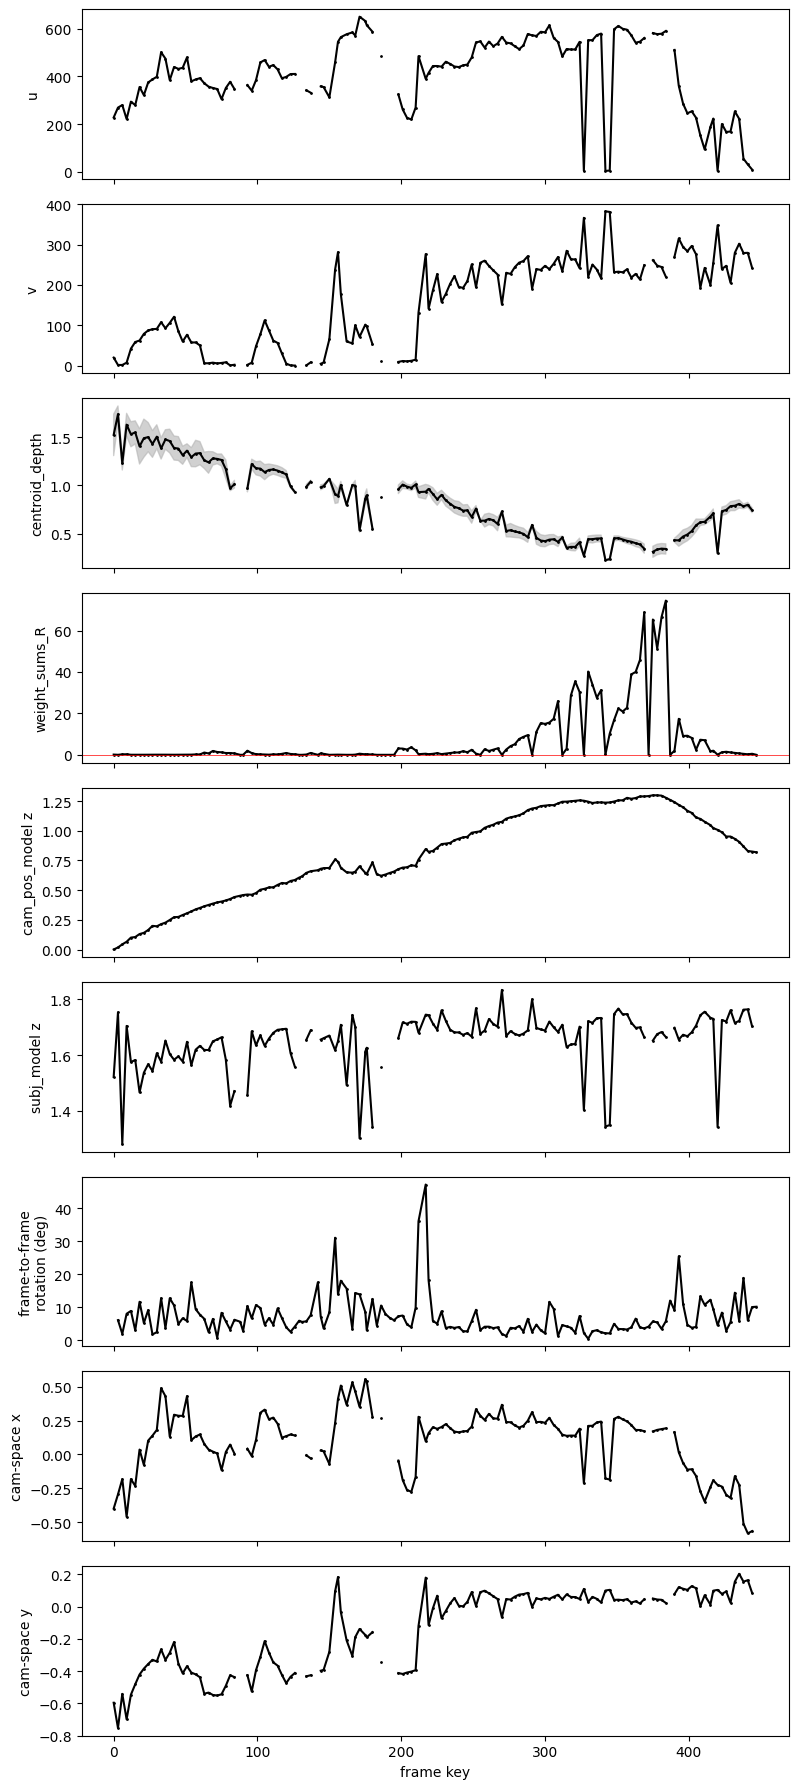

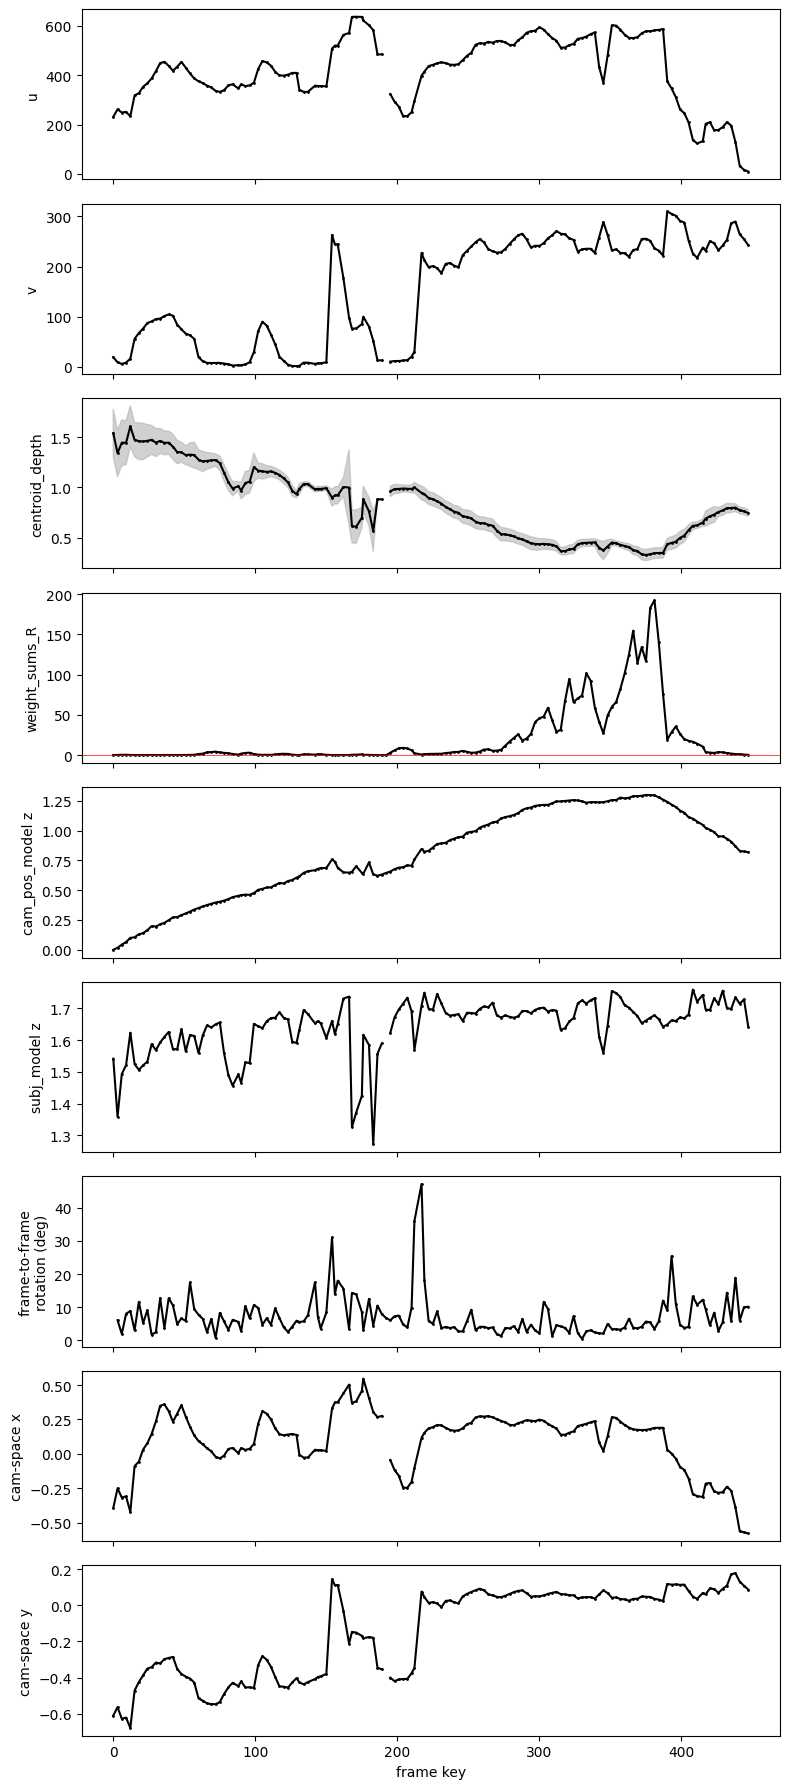

In [18]:
#SUBJECT PPOSITIONING
from Q_subject_analysis import find_mask_centroids_in_model_space

masks_dir_run = masks_dir /"person"/"person-1"

subject_centroids_model_RA1, frame_keys_RA1, depth_spread_model_RA1 = find_mask_centroids_in_model_space(
    recon, masks_dir=str(masks_dir_run), RA = 1, analyse = True
)
subject_positions_model_dict = dict(zip(frame_keys_RA1, subject_centroids_model_RA1))
subject_spread_model_dict    = dict(zip(frame_keys_RA1, depth_spread_model_RA1))  # blob envelope, model-space vector per frame

# make with RA 8 (1s intervals)

subject_centroids_model_RA8, frame_keys_RA8, depth_spread_model_RA8 = find_mask_centroids_in_model_space(
    recon, masks_dir=str(masks_dir_run), RA = 8, analyse = True
)
subject_positions_model_dict_RA8 = dict(zip(frame_keys_RA8, subject_centroids_model_RA8))
subject_spread_model_dict_RA8    = dict(zip(frame_keys_RA8, depth_spread_model_RA8))  # blob envelope, model-space vector per frame


# CAMERA
import matplotlib.pyplot as plt
import numpy as np

FPS = 25
frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
rows = [recon.frame_to_row[f] for f in frame_keys]

extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)

R = extrinsic[:, :3, :3]
t = extrinsic[:, :3, 3]
cam_pos = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
from Thr3D.F_post_recon_processing import positions_to_frame_dict
cam_poses_model_dict = positions_to_frame_dict(cam_pos, frames_for_recon_dir)

In [68]:
print(depth_spread_model_RA8)

[[-5.53715256e-02 -8.55026099e-02  2.16141081e-01]
 [-5.94665322e-02 -7.76536633e-02  2.11785936e-01]
 [-6.89886396e-02 -7.11756925e-02  2.06093874e-01]
 [-3.99062674e-02 -8.25161949e-02  1.98298825e-01]
 [-7.47427829e-02 -7.88184077e-02  1.73360094e-01]
 [-2.78222527e-02 -6.23106592e-02  1.54284663e-01]
 [-5.39554200e-02 -5.71001811e-02  1.65457108e-01]
 [-3.08004374e-02 -6.65023319e-02  1.64993736e-01]
 [-3.98686337e-02 -5.54864301e-02  1.46997178e-01]
 [-3.27463011e-02 -4.89695462e-02  1.31478298e-01]
 [-2.63674264e-02 -4.97019465e-02  1.27642433e-01]
 [-3.88074406e-02 -3.99229776e-02  1.12012931e-01]
 [-3.01788610e-02 -3.89174207e-02  1.09014065e-01]
 [-1.30844930e-02 -4.54316161e-02  1.05850309e-01]
 [-3.35071375e-02 -4.48731294e-02  1.11557459e-01]
 [-2.53864526e-02 -4.18021489e-02  1.05723915e-01]
 [-1.74321678e-02 -3.25371049e-02  9.23559055e-02]
 [-2.98647726e-02 -2.96581068e-02  8.46914581e-02]
 [-1.91701740e-02 -4.06810873e-02  1.08422854e-01]
 [-2.89122627e-02 -4.39827823e-

In [69]:
#check the dict works! nice
print(subject_positions_model_dict)

{0: array([-0.40333894, -0.59589453,  1.52158975]), 3: array([-0.47062506, -0.6733161 ,  1.75328671]), 6: array([-0.34057926, -0.4601993 ,  1.2811931 ]), 9: array([-0.46389084, -0.71792148,  1.70454832]), 12: array([-0.42736334, -0.62746458,  1.57512337]), 15: array([-0.43578027, -0.63364592,  1.58251135]), 18: array([-0.39095924, -0.56312406,  1.46615893]), 21: array([-0.41463649, -0.60349736,  1.53709707]), 24: array([-0.41488145, -0.617751  ,  1.5674581 ]), 27: array([-0.40315263, -0.6004189 ,  1.5429982 ]), 30: array([-0.42451597, -0.63989724,  1.60668189]), 33: array([-0.39482855, -0.61839352,  1.5765044 ]), 36: array([-0.43142974, -0.66636626,  1.65226438]), 39: array([-0.4178576 , -0.64944045,  1.60356769]), 42: array([-0.40236938, -0.63372035,  1.58341491]), 45: array([-0.41317481, -0.645125  ,  1.5955515 ]), 48: array([-0.41235239, -0.60526064,  1.57696015]), 51: array([-0.42179963, -0.66704182,  1.64771858]), 54: array([-0.40921905, -0.61589917,  1.56350672]), 57: array([-0.4

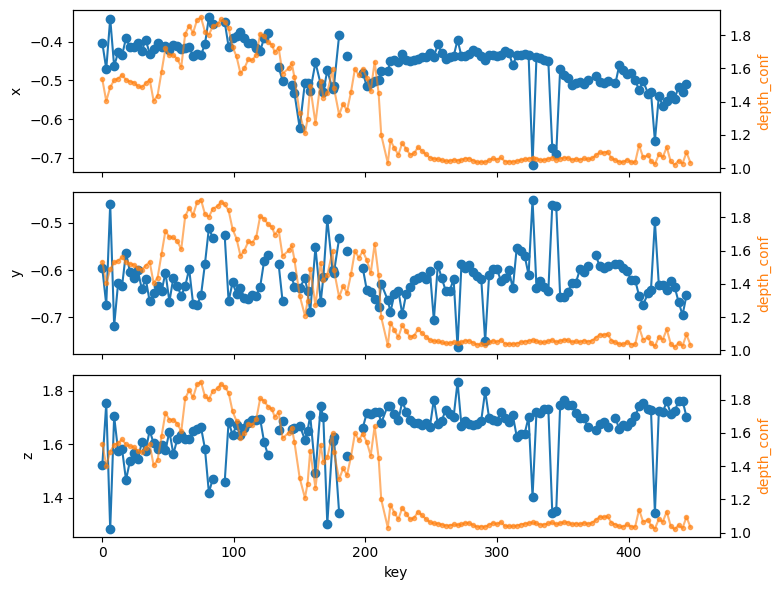

In [70]:
import matplotlib.pyplot as plt

keys = sorted(subject_positions_model_dict.keys())
xs = [subject_positions_model_dict[k][0] for k in keys]
ys = [subject_positions_model_dict[k][1] for k in keys]
zs = [subject_positions_model_dict[k][2] for k in keys]

conf_mean = recon.preds["depth_conf"].mean(dim=(1, 2)).cpu().numpy()


fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
for ax, vals, label in zip(axes, (xs, ys, zs), ("x", "y", "z")):
    ax.plot(keys, vals, marker="o", color="tab:blue")
    ax.set_ylabel(label)

    ax2 = ax.twinx()
    ax2.plot(keys, conf_mean, marker=".", color="tab:orange", alpha=0.6)
    ax2.set_ylabel("depth_conf", color="tab:orange")

axes[-1].set_xlabel("key")
fig.tight_layout()


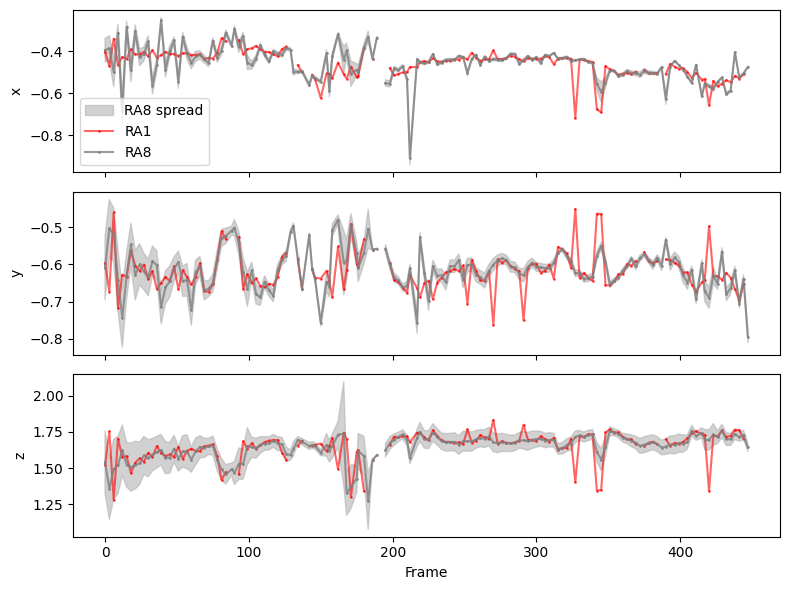

In [83]:
import matplotlib.pyplot as plt
import numpy as np

keys_ra1 = sorted(subject_positions_model_dict.keys())
keys_ra8 = sorted(subject_positions_model_dict_RA8.keys())

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
for i, (ax, label) in enumerate(zip(axes, ("x", "y", "z"))):
    vals_ra1 = np.array([subject_positions_model_dict[k][i] for k in keys_ra1])
    vals_ra8 = np.array([subject_positions_model_dict_RA8[k][i] for k in keys_ra8])
    spread_ra8 = depth_spread_model_RA8[:, i]

    ax.fill_between(keys_ra8, vals_ra8 - spread_ra8, vals_ra8 + spread_ra8, color="0.7", alpha=0.6, label="RA8 spread")
    ax.plot(keys_ra1, vals_ra1, marker="o", color="red", markersize=1, alpha=0.6, label="RA1")
    ax.plot(keys_ra8, vals_ra8, marker="o", color="grey", markersize=1, alpha = 0.8, label="RA8")
    ax.set_ylabel(label)

axes[0].legend()
axes[-1].set_xlabel("Frame")

fig.tight_layout()


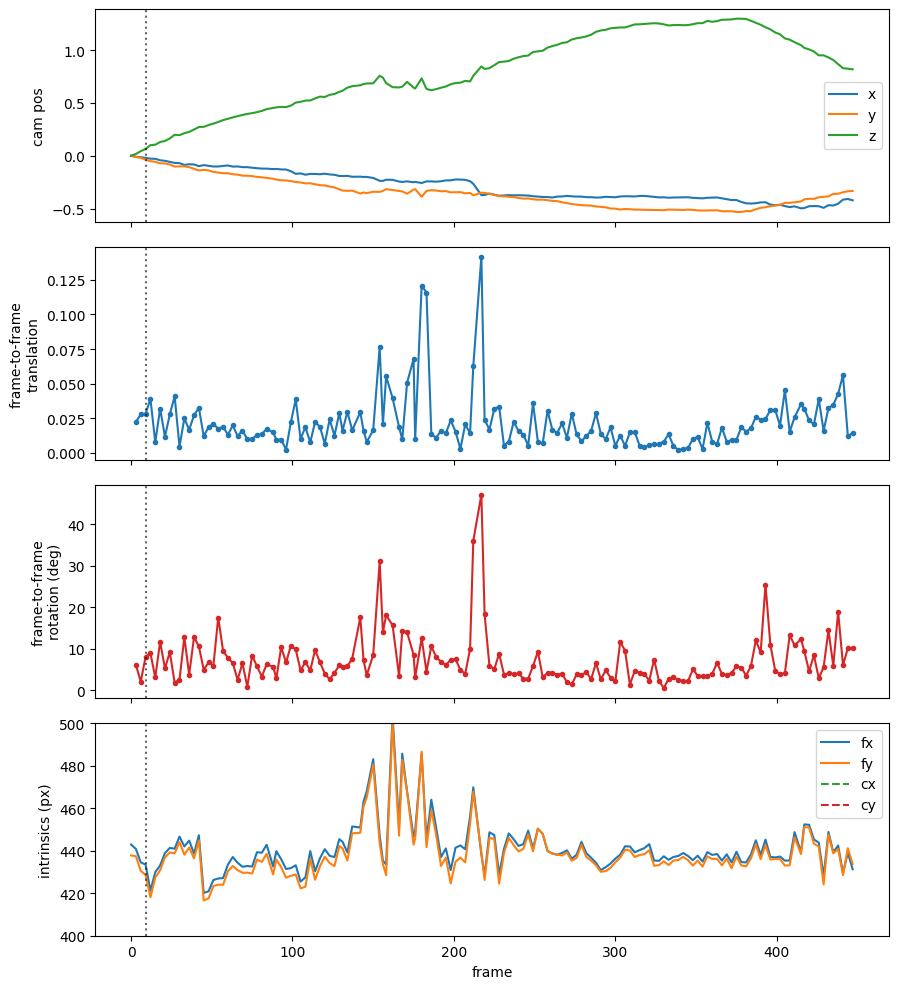

In [ ]:


# frame-to-frame jumps -- translation (m) and rotation (deg), via relative R
trans_jump = np.linalg.norm(np.diff(cam_pos, axis=0), axis=1)
R_rel = np.einsum("nij,nkj->nik", R[1:], R[:-1])  # R_i @ R_{i-1}^T
cos_angle = (np.trace(R_rel, axis1=1, axis2=2) - 1) / 2
rot_jump_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

fx, fy = intrinsic[:, 0, 0], intrinsic[:, 1, 1]
cx, cy = intrinsic[:, 0, 2], intrinsic[:, 1, 2]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(9, 10))

axes[0].plot(frame_keys, cam_pos[:, 0], label="x")
axes[0].plot(frame_keys, cam_pos[:, 1], label="y")
axes[0].plot(frame_keys, cam_pos[:, 2], label="z")
axes[0].set_ylabel("cam pos")
axes[0].legend()

axes[1].plot(frame_keys[1:], trans_jump, marker=".")
axes[1].set_ylabel("frame-to-frame\ntranslation")

axes[2].plot(frame_keys[1:], rot_jump_deg, marker=".", color="tab:red")
axes[2].set_ylabel("frame-to-frame\nrotation (deg)")

axes[3].plot(frame_keys, fx, label="fx")
axes[3].plot(frame_keys, fy, label="fy")
axes[3].plot(frame_keys, cx, label="cx", linestyle="--")
axes[3].plot(frame_keys, cy, label="cy", linestyle="--")
axes[3].set_ylabel("intrinsics (px)")
axes[3].legend()
axes[3].set_xlabel("frame")
axes[3].set_ylim(400,500)

for ax in axes:
    ax.axvline(9, color="k", linestyle=":", alpha=0.6)

fig.tight_layout()
plt.show()


## SAM can't threshold

n = 465
count    465.000000
mean       0.757812
std        0.000000
min        0.757812
25%        0.757812
50%        0.757812
75%        0.757812
max        0.757812
Name: confidence, dtype: float64
(0.75704, 0.75713] |     0 | 
(0.75713, 0.75721] |     0 | 
(0.75721, 0.75728] |     0 | 
(0.75728, 0.75736] |     0 | 
(0.75736, 0.75743] |     0 | 
(0.75743, 0.75751] |     0 | 
(0.75751, 0.75759] |     0 | 
(0.75759, 0.75766] |     0 | 
(0.75766, 0.75774] |     0 | 
(0.75774, 0.75781] |   465 | ############################################################
(0.75781, 0.75789] |     0 | 
(0.75789, 0.75796] |     0 | 
(0.75796, 0.75804] |     0 | 
(0.75804, 0.75812] |     0 | 
(0.75812, 0.75819] |     0 | 
(0.75819, 0.75827] |     0 | 
(0.75827, 0.75834] |     0 | 
(0.75834, 0.75842] |     0 | 
(0.75842, 0.75849] |     0 | 
(0.75849, 0.75857] |     0 | 
count    465.000000
mean       0.757812
std        0.000000
min        0.757812
25%        0.757812
50%        0.757812
75%        0.757812

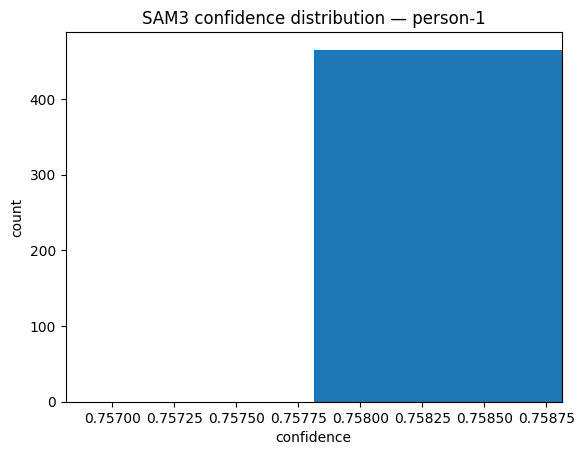

In [74]:
import pandas as pd
#project/Data/304_met_multi_4/015_SAM3_masks/subject_isolation/detections.csv
df = pd.read_csv(masks_dir / "detections.csv")  # or the direct path to detections.csv
person1 = df[df["tracker_id"].astype(str) == "1"]

print(f"n = {len(person1)}")
print(person1["confidence"].describe())

# text histogram
counts, edges = pd.cut(person1["confidence"], bins=20, retbins=True), None
hist = person1["confidence"].value_counts(bins=20, sort=False)
maxc = hist.max()
for interval, count in hist.items():
    bar = "#" * int(60 * count / maxc) if maxc else ""
    print(f"{interval} | {count:5d} | {bar}")

# or a real plot
import matplotlib.pyplot as plt


conf = person1["confidence"]
print(conf.describe())

plt.hist(conf, bins=50, range=(conf.min(), conf.max()))
plt.xlim(conf.min() - 0.001, conf.max() + 0.001)
plt.xlabel("confidence")
plt.ylabel("count")
plt.title("SAM3 confidence distribution — person-1")
plt.show()



In [ ]:
for tid, g in df.groupby("tracker_id"):
    print(tid, g["confidence"].nunique(), g["confidence"].unique()[:5])


0 1 [0.90625]
1 1 [0.7578125]
2 1 [0.734375]
3 1 [0.72265625]
4 1 [0.921875]
5 1 [0.703125]
6 1 [0.921875]
7 1 [0.73828125]
8 1 [0.796875]
9 1 [0.71875]
10 1 [0.7265625]
11 1 [0.796875]
12 1 [0.828125]
13 1 [0.73046875]
14 1 [0.76953125]


# Rendering

In [76]:
#BEV SETUP
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles
from Two2D.B_video_processing import available_frames
#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [81]:
#BEV HI RES
#BEV projection mapping of subject to a selected view
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params, BEV_path = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=1.05, 
                   margin_frac=0.05)  
technique = "VGGT_O"
n_frames = 200
thresholds=( 1, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35)
out_dir = case_dir_ / "080_experiments" /"BEVS"
'''
for c in thresholds:
   
        BEV_tile_render_PM(
                        recon, extra_indices, masks_dir=None,
                        confidence_threshold=c, out_path=out_dir / f"{technique}_{n_frames}_BEV_c{c}.png",
                    )'''


[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 88, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 131, 134, 137, 142, 144, 146, 150, 154, 156, 158, 162, 166, 168, 171, 175, 176, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 212, 217, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 415, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447]
min depth tensor(0.0259, device='cuda:0')
torch.Size([21437256, 3])
mins, maxes and ranges -0.8425601094961166 0.21904647052288057 1.061606580018997 -0.012638587877154356 1.9790110256522895 1.991649613529444
scale - original 3184.1705999132564


'\nfor c in thresholds:\n\n        BEV_tile_render_PM(\n                        recon, extra_indices, masks_dir=None,\n                        confidence_threshold=c, out_path=out_dir / f"{technique}_{n_frames}_BEV_c{c}.png",\n                    )'

In [82]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#n_frames is a directly controllable parameter -- not derived from duration*fps.
from P_trace_overlayer import BEV_trace_overlay
#takes BEV from assets dir
BEV_trace_overlay(
    recon,
    extra_indices,
    new_view,
    ortho_params,
    subject_positions=subject_positions_model_dict,
    n_frames=90,
    bev_png_path = BEV_path
)


frame 0000 t_frac=0.0000 [camera] virtual_frame=0.0 pos_px=(456.8, 1073.1)
frame 0000 t_frac=0.0000 [subject] virtual_frame=0.0 pos_px=(228.5, 223.4)
frame 0001 t_frac=0.0112 [camera] virtual_frame=5.0 pos_px=(450.3, 1054.4)
frame 0001 t_frac=0.0112 [subject] virtual_frame=5.0 pos_px=(228.9, 227.4)
frame 0002 t_frac=0.0225 [camera] virtual_frame=10.0 pos_px=(444.9, 1031.3)
frame 0002 t_frac=0.0225 [subject] virtual_frame=10.0 pos_px=(230.0, 230.9)
frame 0003 t_frac=0.0337 [camera] virtual_frame=15.1 pos_px=(441.3, 1016.1)
frame 0003 t_frac=0.0337 [subject] virtual_frame=15.1 pos_px=(230.3, 229.2)
frame 0004 t_frac=0.0449 [camera] virtual_frame=20.1 pos_px=(432.0, 998.9)
frame 0004 t_frac=0.0449 [subject] virtual_frame=20.1 pos_px=(230.7, 225.4)
frame 0005 t_frac=0.0562 [camera] virtual_frame=25.1 pos_px=(423.9, 977.3)
frame 0005 t_frac=0.0562 [subject] virtual_frame=25.1 pos_px=(231.9, 222.6)
frame 0006 t_frac=0.0674 [camera] virtual_frame=30.1 pos_px=(418.9, 966.9)
frame 0006 t_frac=0

PosixPath('/workspace/project/Data/304_met_multi_4/090_assets/bev_trace_frames')

In [ ]:
#Convert into model space and export into plys

#camera
ext = recon.preds["extrinsic"][0].clone()
#save
_ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , 
                                        conf_threshold=1, 
                                        R=ext[:,0:3], 
                                        t=ext[:,3], 
                                        s=1.02)
print(predictions_path_)


In [ ]:
# Cell — PLY visualisation
import importlib, sys
sys.path.insert(0, str(project_root / "src"))
from Thr3D.F_cut3r_vis import visualise_cut3r
visualisation_dir = case_dir_   /  VGGT_O_output_dir
#visualisation_dir = case_dir_   /  CUT3R_output_dir
visualise_cut3r(visualisation_dir)


# Producer Workflow


In [ ]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": True,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": True,
    "RECON_3D": True,
    "VGGT_O_RECON": False,
    "MULTI_PART_RECON": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : True,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"RECON_CAM_POSES", "RECON_3D", "VGGT_O_RECON", "MULTI_PART_RECON",
             "GOOGLE_MAP", "BEV_MAP" "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [87]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")



re_caching video


**00:00 - 00:07**
A police bodycam video captures officers confronting a suspect in a narrow residential alleyway lined with garages. An officer is seen walking towards a suspect wearing a yellow jacket who is brandishing a large sword. The officer recording the footage repeatedly yells commands at the suspect to "Put it down!" while moving forward to support his colleague.

**00:07 - 00:15**
As the officers close in on the suspect, they continue to demand that he drop the weapon. One officer draws and fires a taser, but the suspect aggressively lunges forward and swings the sword, striking one of the officers. Despite the violent confrontation, the suspect retreats further down the alleyway as officers try to maintain a perimeter.

**00:15 - 00:24**
Immediately following the attack, the injured officer is seen recoiling from the blow. Realizing the severity of the injury, the officer filming urgently calls out for a tourniquet to treat his wounded colleague. He then rushes back toward

## Producer draft 1

In [9]:
Question = "give a detailed account of what happened - including who was where and when?"

In [43]:
#PRODUCER DRAFT 1
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from producer_agent_execution import run_producer_agent, build_producer_prompt_pass1
analysis_2d_for_decisions=[]
prompt = build_producer_prompt_pass1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")


[15:23:44 +  0.00s] run_producer_agent: start
[15:23:44 +  0.00s] thread: start
[15:23:44 +  0.00s] event loop: created
[15:23:44 +  0.00s] query: start


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[15:24:02 + 18.37s] turn 1 usage (claude-sonnet-5): in=2 out=2 cache_write=0 cache_read=13007
[15:24:15 + 31.09s] turn 2 usage (claude-sonnet-5): in=2 out=2 cache_write=0 cache_read=13007
[15:24:15 + 31.09s] tool call: Write (/workspace/project/Data/304_met_multi_4/012_agent_p_output/304_met_multi_4_paper_edit_draft.json)
[15:24:21 + 37.35s] turn 3 usage (claude-sonnet-5): in=2 out=4 cache_write=3422 cache_read=13007
[15:24:21 + 37.56s] result: status=success num_turns=2 duration_ms=36463 duration_api_ms=38453 cost_usd=0.0865142
[15:24:21 + 37.56s] result usage (aggregate): {'input_tokens': 4, 'cache_creation_input_tokens': 3422, 'cache_read_input_tokens': 26014, 'output_tokens': 3776, 'server_tool_use': {'web_search_requests': 0, 'web_fetch_requests': 0}, 'service_tier': 'standard', 'cache_creation': {'ephemeral_1h_input_tokens': 3422, 'ephemeral_5m_input_tokens': 0}, 'inference_geo': 'not_available', 'iterations': [{'input_tokens': 2, 'output_tokens': 429, 'cache_read_input_tokens': 

In [14]:
# FORMAT PRODUCER OUTPUT into HTML and FLAGS
import importlib
import json
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
import render_paper_edit
importlib.reload(render_paper_edit)

from render_paper_edit import render_and_save, derive_and_save_flags

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(paper_edit_json_path, producer_flags.keys())
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))


=== Rendered HTML ===
  /workspace/project/Data/304_met_multi_4/012_agent_p_output/304_met_multi_4_draft_paper_edit.html

=== Derived flags (from 304_met_multi_4_draft_flags.json) ===
{
  "RECON_CAM_POSES": false,
  "RECON_3D": false,
  "CUT3R_RECON": false,
  "MEGA_SAM_RECON": false,
  "VGGT_RECON": false,
  "VGGT_O_RECON": false,
  "MULTI_PART_RECON": false,
  "GOOGLE_MAP": false,
  "MASK_OVERLAYS": false,
  "MULTICAM": false
}


mapping
moving
subject moved 0.22468603808114576 m
subject moved in a 321.6843301856454 direction


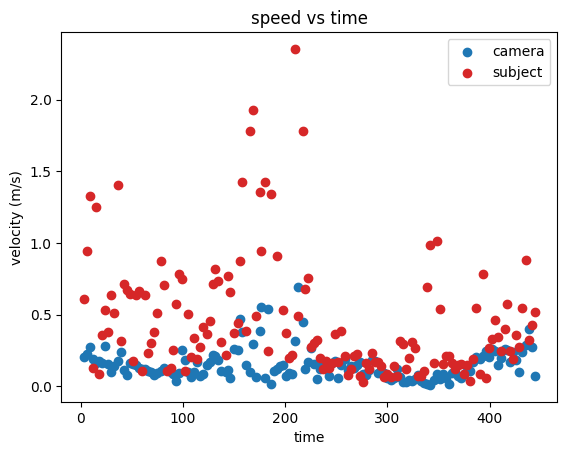

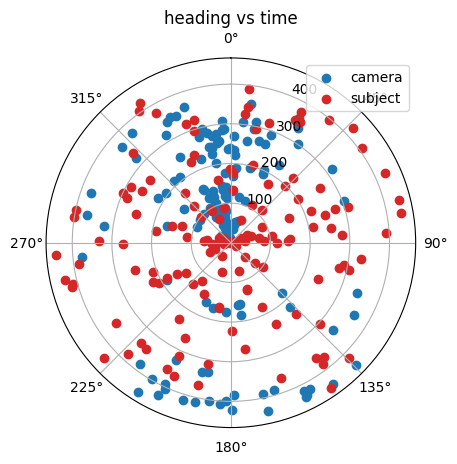

In [28]:
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting

#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_model_dict,subject_positions_model_dict_RA8),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(subject_positions_model_dict_RA8, cam_poses_model_dict)



Text(0.5, 1.0, 'Subject position (color = time)')

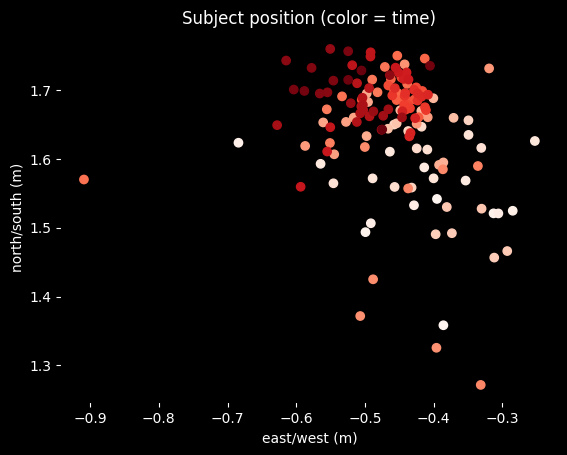

In [ ]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
pts = np.array([subject_positions_model_dict_RA8[k] for k in sorted(subject_positions_model_dict_RA8)])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position (color = time)")


In [44]:
#find the cut points

import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions)

PosixPath('/workspace/project/Data/304_met_multi_4/012_agent_p_output/304_met_multi_4_paper_edit_draft.json')

# Producer 2

In [45]:
#run producer again
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from producer_agent_execution import run_producer_agent, build_producer_prompt_pass2

prompt = build_producer_prompt_pass2(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)


[15:29:13 +  0.00s] run_producer_agent: start
[15:29:13 +  0.00s] thread: start
[15:29:13 +  0.00s] event loop: created
[15:29:13 +  0.00s] query: start


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[15:29:55 + 42.59s] turn 1 usage (claude-sonnet-5): in=2 out=2 cache_write=4089 cache_read=11217
[15:30:03 + 50.12s] turn 2 usage (claude-sonnet-5): in=2 out=2 cache_write=4089 cache_read=11217
[15:30:03 + 50.12s] tool call: Write (/workspace/project/Data/304_met_multi_4/012_agent_p_output/304_met_multi_4_paper_edit.json)
[15:30:06 + 53.09s] turn 3 usage (claude-sonnet-5): in=2 out=5 cache_write=4905 cache_read=15306
[15:30:06 + 53.13s] result: status=success num_turns=2 duration_ms=52081 duration_api_ms=53382 cost_usd=0.1404329
[15:30:06 + 53.13s] result usage (aggregate): {'input_tokens': 4, 'cache_creation_input_tokens': 8994, 'cache_read_input_tokens': 26523, 'output_tokens': 5011, 'server_tool_use': {'web_search_requests': 0, 'web_fetch_requests': 0}, 'service_tier': 'standard', 'cache_creation': {'ephemeral_1h_input_tokens': 8994, 'ephemeral_5m_input_tokens': 0}, 'inference_geo': 'not_available', 'iterations': [{'input_tokens': 2, 'output_tokens': 167, 'cache_read_input_tokens': 

In [32]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.
if flags["GOOGLE_MAP"] == True:
    import R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

Cell disabled


In [ ]:
#CAMERA TRANSFORMS - single recon at the moment
#1m up
ext = recon.preds["extrinsic"][9].clone()
ext[1, 3] += 1/16   # lift camera 1m (1/16 scale)

#10m up BEV
ext9 = recon.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=ext9.dtype, device=ext9.device)

ext = Rx @ ext9        # pitch 90° down, camera stays where cam 9 was
ext[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext[1, 3] += 5/16      # forward 5m along cam 9's original heading

In [ ]:

#2D projection mapping of subject to a selected view
from Thr3D.F_post_recon_processing import Reconstruction
from P_projection_mapping import projection_mapping_sequence
from Two2D.B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
print(extra_indices)

recon = recon
point_cloud_xforms = None
subject_positions = projection_mapping_sequence(
    recon         = recon,
    #main_idx      = 3908,
    #extra_indices = range (3854,4397),
    extra_indices = extra_indices,
    #other syntax  [400,4027, 4052, 4065],
    #extra_indices = [extra_indices], - for composite (double [[]])
    #masks_dir     = str(yolo_masks_dir),
    #point_cloud_xforms = point_cloud_xforms
    new_view = ext ,
    
    confidence_threshold = 1
    
    )


[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 88, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 131, 134, 137, 142, 144, 146, 150, 154, 156, 158, 162, 166, 168, 171, 175, 176, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 212, 217, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 415, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 460, 462, 465, 467, 471, 474, 477, 479, 483, 486, 490, 492, 495, 498, 500, 504, 507, 510, 513, 516, 519, 522, 526, 528, 531, 535, 537, 540, 543, 546, 549, 552, 555, 559, 561, 564, 567, 570, 573, 577, 579, 582, 585, 588, 591, 594, 597]
[0]
tensor(2.9765, device='cuda:0')
t

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

In [ ]:
#render projection of 3D points clouds
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir_   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


In [ ]:

#cutr point cloud render
if flags["CUT3R_RECON"] ==True:  
    visualisation_dir = case_dir_   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   



In [ ]:
#4D viewer
if flags["VGGT_O_RECON"] ==True:
     ply_dir = VGGT_O_output_dir  /"ply"  
from U_rendering import view_ply_sequence_with_scenepic
FourD =  view_ply_sequence_with_scenepic(
    ply_dir , 
    point_size=0.01, 
    pattern="*.ply")

scenepic[info]> Disabling VideoWriter due to ImportError


In [ ]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/report_07_Tropea_cafe_cat_03.csv'

In [ ]:
if flags["MAKE_MOVIE"] ==True:
  #MAKING A MOVIE
  '''This controls M_scoring. It's independent of scene recon, so could be placed anywhere'''
  '''bring in M_scoring_controls'''
  from W_video_editor import video_overlay_edit
  movie_start = movie_start
  moveie_end = movie_end
  movie =video_overlay_edit(video_path, 
                            movie_start, 
                            moveie_end, 
                            yolo_masks_dir, 
                            3777, 4557,
                            handles=2, 
                          color=(0, 200, 0), 
                          alpha=0.4) 

NameError: name 'movie_start' is not defined

In [ ]:
if flags["MAKE_MOVIE_CUTS"] == True:
    import W_video_editor
    W_video_editor.find_all_cut_points(video_path)
    W_video_editor.assemble_paper_edit(video_path)
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
video_path = assets_dir() / f"{asset_name}_overlay_video.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()


In [ ]:
# Cell — Populate PowerPoint from CSV
import sys
import importlib
sys.path.insert(0, str(project_root / "src"))

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir_ / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir_ / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))
